<div style="background: linear-gradient(135deg, rgb(233, 92, 36) 0%, rgb(202, 25, 16) 30%, rgb(255, 255, 255) 60%);
            padding: 10px; border-radius: 8px; margin: 10px 0; color: black; font-family: Arial, sans-serif; text-align: center; font-size: 24px;">

# **Retrieval-система по статьям с arXiv**
</div>

# В проекте строим retrieval-систему И выполняем оценку её качества.

**Цель** построить retrieval-систему и оценить её качество на тестовых запросах, а также выполнить профилирование частей модели

**Целевая метрика** - MRR@5 (Mean Reciprocal Rank по топ-5 выдачи).

**Данные:**
- `arxiv-metadata-s.json` - метаданные статей (`id`, `title`, `abstract`, ...);
- `test_sample.csv` - 1000 тестовых запросов (`query`, `id` верной статьи, `abstract`).

**План:**
1. Исследовательский анализ (EDA).
2. Реализация retrieval-системы.
3. Оценка качества системы.
4. Выводы



#### **Окружение:**

```terminal
ОС:                  Linux 6.6.87.2-microsoft-standard-WSL2
Окружение:           WSL (Windows Subsystem for Linux)

Процессор:           
Ядер (физ):          12
Ядер (лог):          24
Модель CPU:          13th Gen Intel(R) Core(TM) i7-13700K

ОЗУ всего:           16.6 GB
PyTorch версия:      2.11.0+cu130
CUDA доступна:       True
GPU:                 NVIDIA GeForce RTX 4070
CUDA версия:         13.0
VRAM всего:          12.9 GB
```

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(250, 90, 37) 0%, rgb(246, 13, 13) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 0. Импорт библиотек</strong>
</div>

In [1]:
import json
import time
import os
from collections import defaultdict
from contextlib import contextmanager
from typing import List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss

from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from torch import Tensor
import torch.nn.functional as F

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(250, 90, 37) 0%, rgb(246, 13, 13) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 1. Исследовательский анализ (EDA) </strong>
</div>

In [2]:
# Нашу воспроизводимость
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Покажем что gpu cuda с нами
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {DEVICE}")

# Занесем основные пути наших данных
DATA_DIR = "/mnt/d/code/ya_neiro/PROJECT_NLP_CV_LLM/Retrieval-система по статьям с arXiv/data"

CORPUS_PATH = os.path.join(DATA_DIR, "arxiv-metadata-s.json")
TEST_PATH = os.path.join(DATA_DIR, "test_sample.csv")
EMB_CACHE = os.path.join(DATA_DIR, "arxiv_doc_embeddings.npy")

Устройство: cuda


Пути есть, перейдем к загрузки наших датасетов

In [3]:
# Загрузка корпуса статей
with open(CORPUS_PATH, encoding="utf-8") as f:
    raw = json.load(f)

corpus_full = pd.DataFrame(raw)
corpus_full.info()


<class 'pandas.DataFrame'>
RangeIndex: 98213 entries, 0 to 98212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              98213 non-null  str   
 1   submitter       97650 non-null  str   
 2   authors         98213 non-null  str   
 3   title           98213 non-null  str   
 4   comments        72275 non-null  str   
 5   journal-ref     31672 non-null  str   
 6   doi             43744 non-null  str   
 7   report-no       6558 non-null   str   
 8   categories      98213 non-null  str   
 9   license         82351 non-null  str   
 10  abstract        98213 non-null  str   
 11  versions        98213 non-null  object
 12  update_date     98213 non-null  str   
 13  authors_parsed  98213 non-null  object
dtypes: object(2), str(12)
memory usage: 131.9+ MB


Что мы по факту видим у нас есть 14 колонок с пропусками, разных Dtype.
Количество строк 98213 штук. Боюсь, что не все колонки мы будем использваоть в работе. Оставил только те, которые будем использовать:
- ключ для выдачи и подсчёта MRR@5 `id`
- тексты документа для эмбеддера `title, abstract`
- распределение тематик, для нашего EDA `categories`

Остальные поля будут только занимать место в памяти и раздувать наш Датафрейм, думаю в нашей работе они будут не нужны

In [4]:
# Оставляем колонки
corpus = corpus_full[["id", "title", "abstract", "categories"]].copy()
# освобождаем память
del raw, corpus_full

corpus.info()
corpus.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 98213 entries, 0 to 98212
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          98213 non-null  str  
 1   title       98213 non-null  str  
 2   abstract    98213 non-null  str  
 3   categories  98213 non-null  str  
dtypes: str(4)
memory usage: 104.4 MB


,id,title,abstract,categories
0,0704.0038,The discrete dipole approximation: an overview...,We present a review of the discrete dipole a...,physics.optics physics.comp-ph
1,0704.0057,High-spin to low-spin and orbital polarization...,We study the interplay of crystal field spli...,cond-mat.str-el
2,0704.0060,Coulomb excitation of unstable nuclei at inter...,We investigate the Coulomb excitation of low...,nucl-th
3,0704.0070,Coincidence of the oscillations in the dipole ...,The fractional Aharonov-Bohm oscillation (FA...,cond-mat.mes-hall
4,0704.0074,Injective Morita contexts (revisited),This paper is an exposition of the so-called...,math.RA


Так, ну что можно сказать:
1. Колонки наши без пропусков судя по info() - уже минус доп работа по обработки
2. id - у нас идет строкой а не номером, и сравнивать с ответами текста нужно как строку или что-то придумать..
3. Тексты у нас англоязычные и судя по всему являются научными

теперь посмотрим на текстовые запросы

In [5]:
# Загрузка тестовых запросов
test = pd.read_csv(TEST_PATH)
test.info()
corpus.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        1000 non-null   str  
 1   abstract  1000 non-null   str  
 2   query     1000 non-null   str  
dtypes: str(3)
memory usage: 1.1 MB


,id,title,abstract,categories
0,0704.0038,The discrete dipole approximation: an overview...,We present a review of the discrete dipole a...,physics.optics physics.comp-ph
1,0704.0057,High-spin to low-spin and orbital polarization...,We study the interplay of crystal field spli...,cond-mat.str-el
2,0704.0060,Coulomb excitation of unstable nuclei at inter...,We investigate the Coulomb excitation of low...,nucl-th
3,0704.0070,Coincidence of the oscillations in the dipole ...,The fractional Aharonov-Bohm oscillation (FA...,cond-mat.mes-hall
4,0704.0074,Injective Morita contexts (revisited),This paper is an exposition of the so-called...,math.RA


Пропусков нет, 1000 строк, id тоже строковый, вроде порядок, глянем согласованности в данных

In [6]:
# чек дубликатов
print(f"Дубликаты id в корпусе: {corpus['id'].duplicated().sum()}")
print(f"Дубликаты id в тесте: {test['id'].duplicated().sum()}")

# чек пустоты, хотя вроде info показал, что нет пропусков
print(f"Пустые аннотации в корпусе: {(corpus['abstract'].str.strip() == '').sum()}")

# есть ли у нас статьи из теста в корпусе?
corpus_ids = set(corpus["id"])
print(f"Покрытие теста корпусом: {test['id'].isin(corpus_ids).sum()} / {len(test)}")



Дубликаты id в корпусе: 0
Дубликаты id в тесте: 0
Пустые аннотации в корпусе: 0
Покрытие теста корпусом: 1000 / 1000


Вроде всё выглядит не плохо, а теперь попробуем взять 200 случайных текстовых строк и сравним аннтацию из текста с аннотацией той же статьи в корпусе, кароче говоря проверим это те же самые тексты или нет.

In [7]:
# совпадение аннотации теста с корпусом
abs_map = corpus.set_index("id")["abstract"]
sample = test.sample(200, random_state=SEED)
match = sum(abs_map.get(r["id"], "").strip() == str(r["abstract"]).strip()
            for _, r in sample.iterrows())

# Возьмем 200 случайных запросов из теста и проверим
print(f"Совпадение аннотаций: {match} / 200")

Совпадение аннотаций: 200 / 200


Вроде гуд, едем дальше. Выделим статистические данные текстов

In [8]:
# текст документа для индексации: заголовок + аннотация.
corpus["doc_text"] = (
    corpus["title"].str.strip().str.replace(r"\s+", " ", regex=True)
    + ". "
    + corpus["abstract"].str.strip().str.replace(r"\s+", " ", regex=True)
)

corpus["doc_len"] = corpus["doc_text"].str.len()
test["q_len"] = test["query"].str.len()

print("Метаданные:")
print(corpus["doc_len"].describe().round(0))
print()
print("Тестовые:")
print(test["q_len"].describe().round(0))

Метаданные:
count    98213.0
mean      1055.0
std        439.0
min         36.0
25%        716.0
50%       1032.0
75%       1373.0
max       3923.0
Name: doc_len, dtype: float64

Тестовые:
count    1000.0
mean      127.0
std        27.0
min        40.0
25%       108.0
50%       124.0
75%       143.0
max       238.0
Name: q_len, dtype: float64


Касательно метаданных статей, мы видим, что средняя длинна и медиана 1055 - 1032 - почти совпадают, можно сказать, что распределение без эсктремальных выбросов. Присутствует небольшой скос вправо, т.к. максимальное значение примерно в 4 раза больше медианы. Касательно тестовых - являются более короткими и однородными средняя и медиана очень близки 124 и 127.

Визуализируем всё дело и взглянем на эту картину

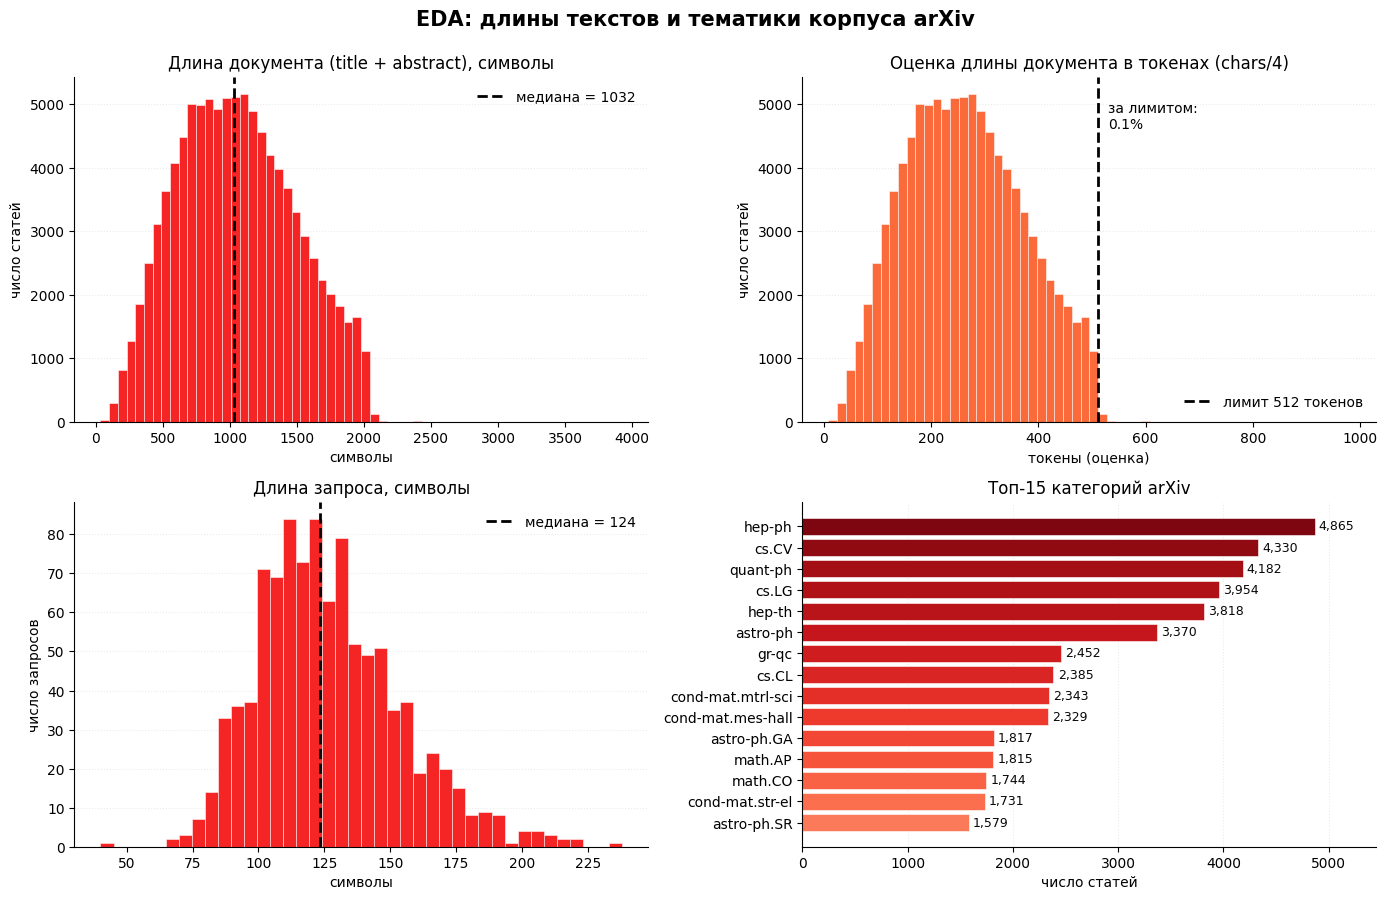

In [ ]:
# Палитра наша
COLORS = {
    "doc": "#f60d0d",
    "tokens": "#fa5a25",
    "query": "#f60d0d",
    "line": "#000000",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("EDA: длины текстов и тематики корпуса arXiv",
             fontsize=15, fontweight="bold", y=0.995)

# Длина документа, символы
ax = axes[0, 0]
ax.hist(corpus["doc_len"], bins=60, color=COLORS["doc"],
        edgecolor="white", linewidth=0.4, alpha=0.9)
med = corpus["doc_len"].median()
ax.axvline(med, color=COLORS["line"], ls="--", lw=2,
           label=f"медиана = {med:.0f}")
ax.set_title("Длина документа (title + abstract), символы", fontsize=12)
ax.set_xlabel("символы")
ax.set_ylabel("число статей")
ax.legend(frameon=False)

# Оценка длины в токенах
ax = axes[0, 1]
ax.hist(corpus["doc_len"] / 4, bins=60, color=COLORS["tokens"],
        edgecolor="white", linewidth=0.4, alpha=0.9)
ax.axvline(512, color=COLORS["line"], ls="--", lw=2, label="лимит 512 токенов")
share = (corpus["doc_len"] / 4 > 512).mean()
ax.text(530, ax.get_ylim()[1] * 0.85, f"за лимитом:\n{share:.1%}",
        color=COLORS["line"], fontsize=10)
ax.set_title("Оценка длины документа в токенах (chars/4)", fontsize=12)
ax.set_xlabel("токены (оценка)")
ax.set_ylabel("число статей")
ax.legend(frameon=False)

# Длина запроса
ax = axes[1, 0]
ax.hist(test["q_len"], bins=40, color=COLORS["query"],
        edgecolor="white", linewidth=0.4, alpha=0.9)
med_q = test["q_len"].median()
ax.axvline(med_q, color=COLORS["line"], ls="--", lw=2,
           label=f"медиана = {med_q:.0f}")
ax.set_title("Длина запроса, символы", fontsize=12)
ax.set_xlabel("символы")
ax.set_ylabel("число запросов")
ax.legend(frameon=False)

# Топ-15 категорий
ax = axes[1, 1]
top_cats = corpus["categories"].str.split().str[0].value_counts().head(15)
grad = plt.cm.Reds(np.linspace(0.95, 0.45, len(top_cats)))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1],
               color=grad[::-1], edgecolor="white", linewidth=0.4)
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(val + 40, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9, color="#080707")
ax.set_title("Топ-15 категорий arXiv", fontsize=12)
ax.set_xlabel("число статей")
ax.set_xlim(0, top_cats.max() * 1.12)


for ax in axes.flat:
    ax.grid(axis="y" if ax is not axes[1, 1] else "x",
            alpha=0.25, linestyle=":")
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

- Длина документов у нас идет аж согласно оси до 4000.. видимо присутствуют какие-то редкие позиции которых не так много.. нет у нас каких-то аномальных гигантов.
- Длина токенов - у нас до 512 токенов практически вся диаграмма находится, и маленький хвостик..чанкинг можно сказать не нужен, лимит токенизатора в 1024 покроет даже хвост.
- Длина запросов - плюс минус похоже на нормальное распределение с небольшими всплесками, основная масса находится примерно от 80 до 16 символов, небольшой хвост от 175 и до 240. 
- Касательно категорий можно сказать, что нет определенной доминирующей темы, и они плавно по количесвтву уменьшаются..

Выведем теперь примеры пар запрос - целевая аннотация

In [10]:
# Примеры пар «запрос — целевая аннотация»
for _, r in test.sample(3, random_state=SEED).iterrows():
    print(f"QUERY:{r['query']}")
    print(f"ID:{r['id']}")
    print(f"ABS: {str(r['abstract']).strip()[:220]}...")
    print("\n")

QUERY:What methods were used to confirm the accuracy of Coulomb gas formalism and bootstrap method in predicting critical properties of the 2D Ising and 3-state Potts models?
ID:hep-lat/9510050
ABS: The critical properties of the 2D Ising and 3-state Potts models are
investigated using Monte Carlo simulations. Special interest is given to
measurement of 3-point correlation functions and associated universal objects,...


QUERY:How can improving machine recognition of processed images lead to universal transferability across different architectures and datasets?
ID:1910.09185
ABS: Recent progress in image recognition has stimulated the deployment of vision
systems at an unprecedented scale. As a result, visual data are now often
consumed not only by humans but also by machines. Existing image proc...


QUERY:What fundamental building blocks generate Pstragowski's category $Syn_E$, where $E$ is a connective ring spectrum?
ID:2402.03257
ABS: If $E$ is a connective ring spectrum, then Pstr

Взглянув на эти результаты пролетает мысль - господи боже мой...Английские тексты ещё и научно-узкоспециализированные, то что надо для человека не плохо знающего английский язык))

Что у нас по итогу выходит:
- каждый запрос представляет собой развёрнутый вопрос по определенной теме или статье о каких-то результатах полученных..
- у нас есть формулы и обозначения в текстах в виде LATEX меток - `$S^{i,j}$` - их оставляем, они являются уникальными помогающими понять суть или же дать верный ответ.
- обрезать текст нельзя будет, наш лимит предложенный в 1024 токена, сможет покрыть любую статью корпуса полностью, т.к. вопрос может касаться середины или конца аннотации.

Касательно EDA если коротко то, у нас пустых аннотаций как таковых нет, почти все документы короче 512 токенов, каждая статья может индексироваться одним вектором - упрощая систему, где будет 1 документ - 1 вектору.
Запросы у нас англоязычные и узкоспециализированные.
По Архитектуре можнео вот так:
| Компонент | Выбор | Почему |
|---|---|---|
| Эмбеддер (bi-encoder) | `Qwen/Qwen3-Embedding-0.6B` | Сильная мультиязычная модель из топа MTEB-ретривала в своём весе; last-token pooling; instruct-промпт для запросов; 0.6B в fp16 примерно 1.2 ГБ VRAM - для моей на RTX 4070 12GB вместе с реранкером должна зайти хорошо|
| Векторный индекс | FAISS `IndexFlatIP` + L2-нормировка векторов | Скалярное произведение нормированных векторов = косинусная близость. 98K на 1024 float32 примерно 0.4 ГБ - должна уложиться в миллисекунды при переборе|
| Реранкер (cross-encoder) | `Qwen/Qwen3-Reranker-0.6B` | Bi-encoder быстро отбирает кандидатов, хоть и грубо|


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(250, 90, 37) 0%, rgb(246, 13, 13) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 2. Реализация retrieval-системы </strong>
</div>

Согласно нашей задачи будем реализовывать три обязательные составляющие нашей системы:
- **`ArxivRetriever`** - код поисковой системы (эмбеддер + FAISS + реранкер);
- **`mrr_at_k`** - функция вычисления целевой метрики;
- **`Profiler`** - функция/класс профилирования всех компонент системы.

In [11]:
class Profiler:
    """Профилировщик компонент системы

    Returns:
        _type_: Накапливает суммарное время и числов вызово по каждому компоненту
    """    
    def __init__(self):
        """Иниты
        """        
        self.times = defaultdict(float)
        self.counts = defaultdict(int)

    @contextmanager
    def track(self, name: str):
        """Замер времени одного блока кода

        Args:
            name (str): имя компонента
        """        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        try:
            yield
        finally:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            self.times[name] += time.perf_counter() - t0
            self.counts[name] += 1

    def report(self) -> pd.DataFrame:
        """Сводная

        Returns:
            pd.DataFrame: строки компоненты и колонки
        """        
        rows = [{
            "компонент": name,
            "вызовов": self.counts[name],
            "всего, с": round(self.times[name], 3),
            "среднее, мс": round(1000 * self.times[name] / self.counts[name], 2),
        } for name in self.times]
        return (pd.DataFrame(rows)
                .sort_values("всего, с", ascending=False)
                .reset_index(drop=True))

    def reset(self):
        """Обнуление всех накомплений
        """        
        self.times.clear()
        self.counts.clear()

In [12]:
class ArxivRetriever:
    
    """Наша двухступенчатая retrieval-система
    """    

    TASK = "Given a web search query, retrieve relevant passages that answer the query"

    def __init__(
        self,
        embedder_name: str = "Qwen/Qwen3-Embedding-0.6B",
        reranker_name: str = "Qwen/Qwen3-Reranker-0.6B",
        device: Optional[str] = None,
        max_doc_length: int = 1024,
        profiler: Optional[Profiler] = None,
    ):
        
        """Иниты

        Args:
            embedder_name (str, optional): Модель 1. Defaults to "Qwen/Qwen3-Embedding-0.6B".
            reranker_name (str, optional): Модель 2. Defaults to "Qwen/Qwen3-Reranker-0.6B".
            device (Optional[str], optional): На случай выбора девайса. Defaults to None.
            max_doc_length (int, optional): Лимит токенов, который мы ранее определели. Defaults to 1024.
            profiler (Optional[Profiler], optional): Профилировщик. Defaults to None.
        """  
              
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.max_doc_length = max_doc_length
        self.profiler = profiler or Profiler()

        # Bi-encoder (эмбеддер)
        with self.profiler.track("Загрузка эмбеддера"):
            self.emb_tokenizer = AutoTokenizer.from_pretrained(
                embedder_name, padding_side="left")
            self.embedder = AutoModel.from_pretrained(
                embedder_name, dtype=torch.float16).to(self.device)
            self.embedder.eval()

        # Cross-encoder (реранкер)
        with self.profiler.track("Загрузка реранкера"):
            self.rr_tokenizer = AutoTokenizer.from_pretrained(
                reranker_name, padding_side="left")
            self.reranker = AutoModelForCausalLM.from_pretrained(
                reranker_name, dtype=torch.float16).to(self.device)
            self.reranker.eval()

        # Служебные токены реранкера (формат yes/no из карточки Qwen3-Reranker)
        self.rr_max_length = 2048
        self.token_false_id = self.rr_tokenizer.convert_tokens_to_ids("no")
        self.token_true_id = self.rr_tokenizer.convert_tokens_to_ids("yes")
        prefix = ("<|im_start|>system\nJudge whether the Document meets the requirements "
                  "based on the Query and the Instruct provided. Note that the answer can "
                  "only be \"yes\" or \"no\".<|im_end|>\n<|im_start|>user\n")
        suffix = "<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n"
        self.rr_prefix_tokens = self.rr_tokenizer.encode(prefix, add_special_tokens=False)
        self.rr_suffix_tokens = self.rr_tokenizer.encode(suffix, add_special_tokens=False)

        # База
        self.index: Optional[faiss.Index] = None
        self.ids: List[str] = []
        self.doc_texts: List[str] = []

    # Эмбеддинги (bi-encoder)
    @staticmethod
    def last_token_pool(last_hidden_states: Tensor, attention_mask: Tensor) -> Tensor:
        
        """last_token_pool - эмбеддинг текста = скрытое состояние последнего токена

        Args:
            last_hidden_states (Tensor): выход модели, (batch, seq_len, hidden)
            attention_mask (Tensor): Маска реальных токенов (batch, seq_len)

        Returns:
            Tensor: эмбеддинги текстов (batch, hidden)
        """        
        
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[
            torch.arange(batch_size, device=last_hidden_states.device),
            sequence_lengths]

    @torch.no_grad()
    def _embed(self, texts: List[str], is_query: bool = False) -> np.ndarray:
        
        """Кодирует список текстов в эмбеддинги

        Args:
            texts (List[str]): тексты для кодировки
            is_query (bool, optional): (True) Запросы и (False) документы. Defaults to False.

        Returns:
            np.ndarray: матрица эмбеддингов
        """     
           
        if is_query:
            texts = [f"Instruct: {self.TASK}\nQuery:{t}" for t in texts]
        inputs = self.emb_tokenizer(
            texts, padding=True, truncation=True,
            max_length=self.max_doc_length, return_tensors="pt",
        ).to(self.device)
        outputs = self.embedder(**inputs)
        emb = self.last_token_pool(outputs.last_hidden_state, inputs["attention_mask"])
        emb = F.normalize(emb, p=2, dim=1)
        return emb.float().cpu().numpy()

    def embed_corpus(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        
        """ батчевый расчет эмбеддиногов всего корпуса

        Args:
            texts (List[str]): доки корпуса
            batch_size (int, optional): Размер батча. Defaults to 32.

        Returns:
            np.ndarray: эмбденды в исходном порядке текстов
        """   
             
        order = np.argsort([len(t) for t in texts])
        sorted_texts = [texts[i] for i in order]

        chunks = []
        t_start = time.perf_counter()
        for i in range(0, len(sorted_texts), batch_size):
            with self.profiler.track("Эмбеддинг корпуса (батч)"):
                chunks.append(self._embed(sorted_texts[i:i + batch_size]))
            if (i // batch_size) % 200 == 0:
                done = min(i + batch_size, len(sorted_texts))
                speed = done / (time.perf_counter() - t_start)
                print(f"  {done:>6}/{len(sorted_texts)}  ({speed:.0f} док/с)", end="\r")
        print()

        emb_sorted = np.concatenate(chunks)
        emb = np.empty_like(emb_sorted)
        emb[order] = emb_sorted
        return emb


    # Построение индекса
    def build_index(self, ids: List[str], texts: List[str],
                    batch_size: int = 32, cache_path: Optional[str] = None) -> None:
        
        """Строим посковую базу 

        Args:
            ids (List[str]): id статей
            texts (List[str]): тексты документов
            batch_size (int, optional): Батч размер. Defaults to 32.
            cache_path (Optional[str], optional): путь к кэшу эмбенда. Defaults to None.
        """        

        self.ids = list(ids)
        self.doc_texts = list(texts)

        if cache_path and os.path.exists(cache_path):
            print(f"Загрузка эмбеддов из кэша: {cache_path}")
            embeddings = np.load(cache_path)
            assert embeddings.shape[0] == len(texts), "Кэш не соответствует корпусу"
        else:
            print("Расчет эмбеддинги корпуса")
            embeddings = self.embed_corpus(texts, batch_size=batch_size)
            if cache_path:
                np.save(cache_path, embeddings)
                print(f"Эмбеддинги сохранены в {cache_path}")

        with self.profiler.track("Построение FAISS-индекса"):
            self.index = faiss.IndexFlatIP(embeddings.shape[1])
            self.index.add(embeddings.astype("float32"))

        mem_mb = self.index.ntotal * embeddings.shape[1] * 4 / 2**20
        print(f"База построена: {self.index.ntotal:,} векторов"
              f"размерности {embeddings.shape[1]} (~{mem_mb:.0f} МБ в RAM)")



    # Поиск (bi-encoder + FAISS)
    def search(self, queries: List[str], k: int = 10,
               query_batch_size: int = 64) -> List[List[dict]]:
        
        """Векторный поиск топ кандидатов для списка запросов

        Args:
            queries (List[str]): текстовые запросы
            k (int, optional): количество топов. Defaults to 10.
            query_batch_size (int, optional): размер батча кодирования. Defaults to 64.

        Raises:
            ValueError: если индекс не построен

        Returns:
            List[List[dict]]: Список кандидатов выходит по убыванию близости
        """        

        if self.index is None:
            raise ValueError("Индекс не построен, надо вызвать build_index()")

        results = []
        for i in range(0, len(queries), query_batch_size):
            batch = queries[i:i + query_batch_size]
            with self.profiler.track("Эмбеддинг запроса"):
                q_emb = self._embed(batch, is_query=True)
            with self.profiler.track("Поиск FAISS"):
                scores, idxs = self.index.search(q_emb.astype("float32"), k)
            for row_s, row_i in zip(scores, idxs):
                results.append([
                    {"id": self.ids[j], "text": self.doc_texts[j], "score": float(s)}
                    for s, j in zip(row_s, row_i)
                ])
        return results


    # Реранкинг (cross-encoder)
    def _rr_format(self, query: str, doc: str) -> str:
        
        """Сборщик текстов пар - запрос и документ

        Args:
            query (str): запрос пользователя
            doc (str): текст документа

        Returns:
            str: строка 
        """       
         
        return (f"<Instruct>: {self.TASK}\n<Query>: {query}\n<Document>: {doc}")

    def _rr_process_inputs(self, pairs: List[str]):
        
        """Токенизируем пары и оборачиваем их в системный реранкер

        Args:
            pairs (List[str]): Пары наши

        Returns:
            _type_: тензоры
        """        
        
        inputs = self.rr_tokenizer(
            pairs, padding=False, truncation="longest_first",
            return_attention_mask=False,
            max_length=self.rr_max_length
                       - len(self.rr_prefix_tokens) - len(self.rr_suffix_tokens),
        )
        for i, ele in enumerate(inputs["input_ids"]):
            inputs["input_ids"][i] = self.rr_prefix_tokens + ele + self.rr_suffix_tokens
        inputs = self.rr_tokenizer.pad(
            inputs, padding=True, return_tensors="pt", max_length=self.rr_max_length)
        return {k: v.to(self.device) for k, v in inputs.items()}

    @torch.no_grad()
    def _rr_compute_scores(self, inputs) -> List[float]:
        
        """Считаем релевантность пар по логитов токенов

        Args:
            inputs (_type_): тензоры

        Returns:
            List[float]: скор релевантности
        """   
             
        logits = self.reranker(**inputs).logits[:, -1, :]
        true_vec = logits[:, self.token_true_id]
        false_vec = logits[:, self.token_false_id]
        stacked = torch.stack([false_vec, true_vec], dim=1)
        log_probs = torch.nn.functional.log_softmax(stacked.float(), dim=1)
        return log_probs[:, 1].exp().tolist()

    def rerank(self, query: str, candidates: List[dict], batch_size: int = 8) -> List[dict]:
        
        """Переранжовка кандидатов

        Args:
            query (str): запрос вопрос
            candidates (List[dict]): кандидаты из поиска
            batch_size (int, optional): батч. Defaults to 8.

        Returns:
            List[dict]: Кандидаты реранк-скор
        """     
           

        pairs = [self._rr_format(query, c["text"]) for c in candidates]
        scores = []
        for i in range(0, len(pairs), batch_size):
            with self.profiler.track("Реранкинг"):
                inputs = self._rr_process_inputs(pairs[i:i + batch_size])
                scores.extend(self._rr_compute_scores(inputs))
        order = np.argsort(scores)[::-1]
        return [{**candidates[j], "rerank_score": scores[j]} for j in order]


    # Полный пайплайн для одного запроса
    def retrieve(self, query: str, k: int = 5, k_candidates: int = 10,
                 use_reranker: bool = True) -> List[dict]:
        
        """Ну собственно говоря пайплайн

        Args:
            query (str): запрос
            k (int, optional): Колво результатов вывода. Defaults to 5.
            k_candidates (int, optional): кол-во кандидатов. Defaults to 10.
            use_reranker (bool, optional): ступень реранкинга. Defaults to True.

        Returns:
            List[dict]: топ документов
        """        

        candidates = self.search([query], k=k_candidates)[0]
        if use_reranker:
            candidates = self.rerank(query, candidates)
        return candidates[:k]

In [ ]:
def mrr_at_k(pred_ids: List[List[str]], true_ids: List[str], k: int = 5) -> float:
    
    """Считаем метрику

    Args:
        pred_ids (List[List[str]]): Списки id в порядке убывания релевантности
        true_ids (List[str]): верный id
        k (int, optional): Кол-во топа. Defaults to 5.

    Returns:
        float: _description_
    """    
    
    rr = []
    for preds, true in zip(pred_ids, true_ids):
        rank = next((i + 1 for i, p in enumerate(preds[:k]) if p == true), None)
        rr.append(1.0 / rank if rank else 0.0)
    return float(np.mean(rr))

In [14]:
# Добавим мини-тест метрики
assert mrr_at_k([["a", "b"], ["x", "y"], ["q", "w"]], ["a", "y", "z"]) == (1 + 0.5 + 0) / 3
assert mrr_at_k([["a", "b", "c", "d", "e", "f"]], ["f"], k=5) == 0.0
print("mrr_at_k: тесты пройдены")

mrr_at_k: тесты пройдены


Ну всё, делаем инициализацию системы и строим базу

In [15]:
profiler = Profiler()
retriever = ArxivRetriever(profiler=profiler)

retriever.build_index(
    ids=corpus["id"].tolist(),
    texts=corpus["doc_text"].tolist(),
    batch_size=32,
    cache_path=EMB_CACHE,
)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Загрузка эмбеддов из кэша: /mnt/d/code/ya_neiro/PROJECT_NLP_CV_LLM/Retrieval-система по статьям с arXiv/data/arxiv_doc_embeddings.npy
База построена: 98,213 векторовразмерности 1024 (~384 МБ в RAM)


Проведем один запрос через  всю систему и взглянем как это будет выглядеть.

In [17]:
q_example = test.iloc[0]
print("QUERY:", q_example["query"])
print("TRUE ID:", q_example["id"])
print()

top = retriever.retrieve(q_example["query"], k=5, k_candidates=10, use_reranker=True)
for rank, item in enumerate(top, 1):
    mark = "Ответ" if item["id"] == q_example["id"] else ""
    print(f"{rank}. [{item['id']}] score={item.get('rerank_score', item['score']):.4f} {mark}")
    print(f"   {item['text'][:110]}...")

QUERY: What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
TRUE ID: 2412.16732



/home/xndrf/dl_env311/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2356: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


1. [2412.16732] score=0.9999 Ответ
   Crystal structure of Nd10.67Pt4O24, a new neodymium platinate. A new platinate was recently discovered when Nd...
2. [2312.08738] score=0.0053 
   Combined Thermal Expansion and Hydrolytic Stability Study of Lanthanide Vanadates LnVO4 and CaLnZr(VO4)3 (Ln =...
3. [2507.17040] score=0.0042 
   A Novel Discovery of Negative Thermal Expansion in Rare-earth Pyrochlore through Anion Order-Disorder Transiti...
4. [1511.08314] score=0.0015 
   Synthesis and structure of tetragonal Bi12.5Nd1.5ReO24.5. The Bi12.5Nd1.5ReO24.5 tetragonal phase has been syn...
5. [1312.1576] score=0.0001 
   Magnetic properties of ferromagnetic Pu2Pt3Si5. The structural, magnetic, and thermodynamic properties of a ne...


У нас реранкер почти на 100 процентов уверен, что статья Nd10.67Pt4O24 отвечает на наш вопрос.. ну и соответственно остальные имеют уже слишком низкий процент вероятности правильного ответа. Ну и ответ в вопросе практически соблюдался. Думаю, что можно переходить к этапу оценки качества системы и выполнить все текстовые запросы и посчитать нашу метрику

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, #fa5a25 0%, #f60d0d 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 3. Оценка качества системы </strong>
</div>

In [ ]:
queries = test["query"].tolist()
true_ids = test["id"].tolist()

# векторный поиск топ-10 кандидатов для всех запросов
profiler.reset()

t0 = time.perf_counter()
candidates_all = retriever.search(queries, k=10, query_batch_size=64)
t_search = time.perf_counter() - t0

biencoder_pred = [[c["id"] for c in cands] for cands in candidates_all]
mrr_biencoder = mrr_at_k(biencoder_pred, true_ids, k=5)

print(f"Поиск {len(queries)} запросов: {t_search:.1f} с "
      f"({1000 * t_search / len(queries):.1f} мс/запрос)")
print(f"MRR@5 (только bi-encoder): {mrr_biencoder:.4f}")

Поиск 1000 запросов: 5.2 с (5.2 мс/запрос)

MRR@5 (только bi-encoder): 0.9441


По сути мы без реранкинга прошли наш заданный порог метрики. 
(5.2 мс/запрос) - вроде летит не плохо. Но всё же сделаем реранкинг и взглянем итог

In [19]:
# реранкинг топ-10 кандидатов
t0 = time.perf_counter()
reranked_pred = []
for i, (q, cands) in enumerate(zip(queries, candidates_all)):
    reranked = retriever.rerank(q, cands, batch_size=10)
    reranked_pred.append([c["id"] for c in reranked])
    if i % 100 == 0:
        print(f"{i}/{len(queries)}", end="\r")
t_rerank = time.perf_counter() - t0

mrr_full = mrr_at_k(reranked_pred, true_ids, k=5)

print(f"Реранкинг {len(queries)} запросов: {t_rerank:.1f} с"
      f"({1000 * t_rerank / len(queries):.0f} мс/запрос)")
print(f"MRR@5 (bi-encoder + reranker): {mrr_full:.4f}")

Реранкинг 1000 запросов: 205.7 с(206 мс/запрос)
MRR@5 (bi-encoder + reranker): 0.9663


Получили ещё дополнительный прирост! 

Завернем в датафрейм, чтобы лучше показать наши результаты:

In [ ]:
summary = pd.DataFrame([
    {"конфигурация": "bi-encoder (FAISS top-5)", "MRR@5": round(mrr_biencoder, 4)},
    {"конфигурация": "bi-encoder top-10 + reranker", "MRR@5": round(mrr_full, 4)},
])

display(summary)


,конфигурация,MRR@5
0,bi-encoder (FAISS top-5),0.9441
1,bi-encoder top-10 + reranker,0.9663


Обе конфигурации прошли с запасом заданный порог в 0.91!
Конечно, цена прироста на реранкере в 40 раз дороже в сравнении с первой ступенью вектороного поиска - но всё же. 
В целом по достижению результата метрик и выбора конфигурации зависит больше от требований заказчика или продукта. И выбор между точность и скоростью на плечах заказчика. 

Построим график сравнительный времени по компонентам и по запросам

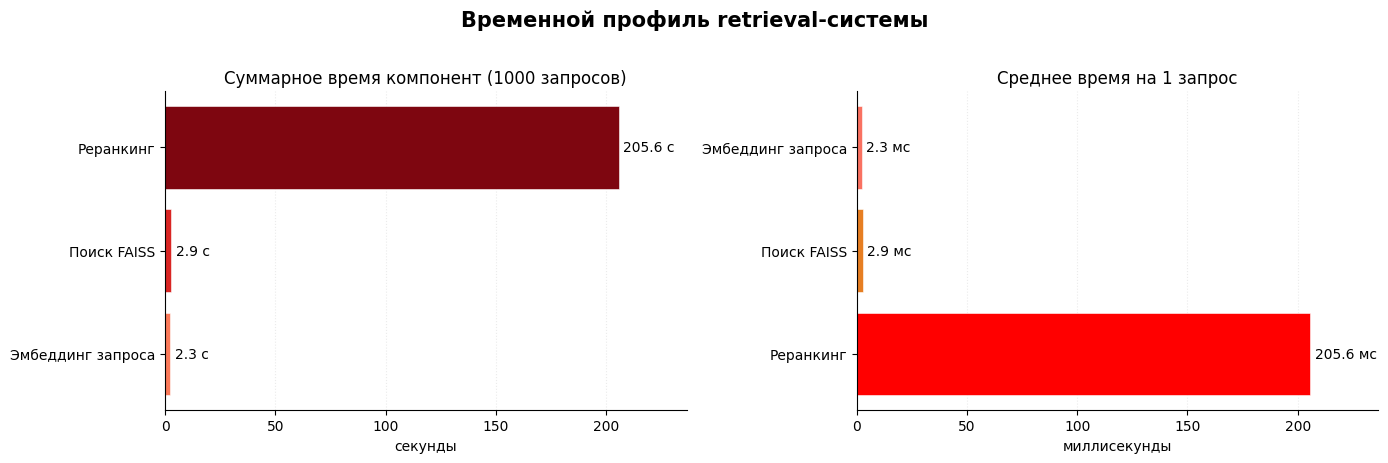

In [47]:
report = profiler.report()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle("Временной профиль retrieval-системы",
             fontsize=15, fontweight="bold", y=1.02)

# Суммарное время по компонентам
ax = axes[0]
vals = report["всего, с"][::-1]
grad = plt.cm.Reds(np.linspace(0.45, 0.95, len(vals)))
bars = ax.barh(report["компонент"][::-1], vals,
               color=grad, edgecolor="white", linewidth=0.4)
for bar, v in zip(bars, vals):
    ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f} с", va="center", fontsize=10, color="#000000")
ax.set_title("Суммарное время компонент (1000 запросов)", fontsize=12)
ax.set_xlabel("секунды")
ax.set_xlim(0, max(vals) * 1.15)

# Среднее время на 1 запрос по стадиям пайплайна
ax = axes[1]
per_query = {
    "Эмбеддинг запроса": 1000 * profiler.times["Эмбеддинг запроса"] / len(queries),
    "Поиск FAISS": 1000 * profiler.times["Поиск FAISS"] / len(queries),
    "Реранкинг": 1000 * profiler.times["Реранкинг"] / len(queries),
}
stages = list(per_query.keys())[::-1]
vals_q = list(per_query.values())[::-1]
colors_q = ["#FF0000", "#E67E22", "#F97161"][:len(vals_q)]
bars = ax.barh(stages, vals_q, color=colors_q, edgecolor="white", linewidth=0.4)
for bar, v in zip(bars, vals_q):
    ax.text(v + max(vals_q) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f} мс", va="center", fontsize=10, color="#000000")
ax.set_title("Среднее время на 1 запрос", fontsize=12)
ax.set_xlabel("миллисекунды")
ax.set_xlim(0, max(vals_q) * 1.15)

for ax in axes:
    ax.grid(axis="x", alpha=0.25, linestyle=":")
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

На основе временного профиля можно сказать, что Реранкинг больше всего времени систет, эмбеддинг и FAISS на его фоне выглядят бесплатными по времени..И ещё раз скажем о том, что обе конфигурации проходят заданный пород, и реранкер будет чисто опциональное требование по точности продукта

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(250, 90, 37) 0%, rgb(246, 13, 13) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 4. Выводы </strong>
</div>

По итогу построена двухступенчатая retrieval-система по 98 213 статьям arXiv: **Qwen3-Embedding-0.6B + FAISS IndexFlatIP → Qwen3-Reranker-0.6B**. Каждая статья (title + abstract) кодируется одним вектором, мы это при EDA обнаружили, что чанкинг не нужен.

### Результаты качества

| Конфигурация | MRR@5 | Латентность |
|---|---|---|
| bi-encoder (FAISS top-5) | 0.9441 | ~5 мс/запрос |
| bi-encoder top-10 + reranker | 0.9663 | ~211 мс/запрос |

Целевая метрика достигнута уже первой ступенью; реранкер добавляет +0.0222 MRR, исправляя ранжирование у запросов с близкими соседями внутри одной научной области.

Временной профиль предельно асимметричен. Эмбеддинг запроса (2.3 мс) и точный перебор 98K векторов в FAISS (2.9 мс) практически бесплатны - приближённые индексы (IVF/HNSW) на этом масштабе не нужны. 

Что касается улучений ускорений - имеет смысл оптимизировать только реранкер на мой взгляд. Плюс можно сократить число кандидов с 10 до 5.
Касательно продуктового выбора - то тут компромис между скоростью и качеством, но в целом качество хорошее при обоих вариантов. С другой стороны тут узкоспециализированные вещи, и на мой взгляд чем точнее - тем лучше, и скоростью можно принебречь